# Demand-tilt layer on top of P2 — an exploration

**Not part of the pipeline, not the recommendation.** Notebooks 01–07 are the
project. This one probes a follow-on question: *can a demand-based ("surge") tilt
sit on top of the inflation-timing rule P2, in this high-inflation setting?*

**The "defensible version" tested here:**

* keep **P2 (τ = 6%)** as the timing rule — reset only when cumulative inflation ≥ τ;
* at **each reset**, multiply the real target by `1 + tilt`, where `tilt` comes
  from *observable* demand shifters, not an estimated elasticity;
* **upward-only** (`tilt ≥ 0`) — demand is inelastic and there is no evidence
  data-driven discounts recover occupancy, so cuts are the risky direction;
* **capped** at `δ_max ∈ {3, 5, 8}%` so it cannot overwhelm the inflation restore
  or push the real price outside the fairness band.

**Data limits.** The panel is monthly, city × category. Of the shifters a real
surge layer wants — booking pace / lead-time pickup, a confirmed event calendar,
real exchange-rate competitiveness for inbound tourists — **none are in
EHOBA/INDEC**. What the panel supports: occupancy vs its seasonal norm,
travellers vs their seasonal norm, an occupancy-momentum ("pace") proxy, and a
high-season flag. This is a feasibility probe with what's available.

**Output** `outputs/tables/demand_tilt_backtest.csv`, `outputs/figures/08_tilt_*.png`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SRC = Path.cwd() / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog
import policies as PL
import pricing_eval as EV

LOG = AuditLog("08_demand_tilt")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

df = pd.read_parquet(C.P_ANALYSIS).rename(columns={"infl_mom_gba_frac": "infl_mom"})
CATS = C.PRESENT_CATEGORIES                       # 4 star tiers + composite
LAB = C.CATEGORY_LABELS
TAU = 0.06                                        # frozen from notebook 05
DELTA_GRID = [0.0, 0.03, 0.05, 0.08]
HI_SEASON = {1, 2, 7}                             # BA summer + winter break
print("categories:", [LAB[c] for c in CATS])
print("windows: train", C.TRAIN_SEGMENTS, "| valid", C.VALID_SEGMENT, "| test", C.TEST_SEGMENT)

categories: ['1-2 star', '3 star', '4 star', '5 star', 'Total (composite)']
windows: train [('2018-01-01', '2019-12-01'), ('2022-01-01', '2022-12-01')] | valid ('2023-01-01', '2023-12-01') | test ('2024-01-01', '2025-11-01')


## 1 · Observable demand shifters (panel-only, no look-ahead)

Per category, all from information available at **t−1** and against
**training-period** seasonal norms:

| shifter | definition | reads as |
|---|---|---|
| `occ_gap` | trailing-3mo room occupancy − its calendar-month train mean | demand hotter / cooler than seasonal norm |
| `trav_gap` | trailing-3mo log travellers − its calendar-month train mean | independent volume signal (2013+; absent for the composite) |
| `occ_yoy` | room occupancy(t−1) − room occupancy(t−13) | is demand *accelerating* into this reset — a "pace" proxy |
| `hi_season` | month ∈ {Jan, Feb, Jul} | a-priori peak-demand flag |

Each is z-scored on the training window; the composite is their mean, plus a
down-weighted centred `hi_season`. The **tilt** is `δ_max · tanh(composite)`,
then clamped to `[0, δ_max]` (upward-only).

In [2]:
def build_shifters(s):
    s = s.sort_values("date").copy()
    tr = s["split"] == "train"
    mon = s["date"].dt.month
    s["_ltrav"] = np.log(s["travelers"])

    occ_norm = s.loc[tr].groupby(s.loc[tr, "date"].dt.month)["room_occupancy"].mean()
    trav_norm = s.loc[tr].groupby(s.loc[tr, "date"].dt.month)["_ltrav"].mean()

    occ_trail = s["room_occupancy"].rolling(3, min_periods=1).mean().shift(1)
    trav_trail = s["_ltrav"].rolling(3, min_periods=1).mean().shift(1)
    s["occ_gap"] = occ_trail.to_numpy() - mon.map(occ_norm).to_numpy()
    s["trav_gap"] = trav_trail.to_numpy() - mon.map(trav_norm).to_numpy()
    s["occ_yoy"] = (s["room_occupancy"].shift(1) - s["room_occupancy"].shift(13)).to_numpy()
    s["hi_season"] = mon.isin(HI_SEASON).astype(float)

    def z(col):
        v = s.loc[tr, col]
        mu, sd = v.mean(), v.std()
        return (s[col] - mu) / (sd if sd and np.isfinite(sd) else 1.0)

    comp = pd.concat([z("occ_gap"), z("trav_gap"), z("occ_yoy")], axis=1).mean(axis=1, skipna=True)
    comp = comp.fillna(0.0) + 0.5 * (s["hi_season"] - float(s.loc[tr, "hi_season"].mean()))
    s["tilt_raw"] = comp.to_numpy()
    return s


def tilt_series(s, delta_max):
    t = delta_max * np.tanh(np.nan_to_num(s["tilt_raw"].to_numpy()))
    return np.clip(t, 0.0, delta_max)                    # upward-only


prep = {}
for c in CATS:
    s = build_shifters(df[df.hotel_category == c])
    prep[c] = dict(s=s, occ_norm=PL.seasonal_occ_norm(s[s.split == "train"]),
                   tgt=EV.target_real_rate(s))

(prep["stars_4"]["s"].query("date >= '2023-06-01'").set_index("date")
 [["occ_gap", "trav_gap", "occ_yoy", "hi_season", "tilt_raw"]].head(10).round(2))

,occ_gap,trav_gap,occ_yoy,hi_season,tilt_raw
date,,,,,
2023-06-01,8.09,0.11,4.63,0.0,0.89
2023-07-01,-4.95,-0.18,3.61,1.0,0.43
2023-08-01,5.29,0.01,1.27,0.0,0.37
2023-09-01,0.08,-0.00,2.86,0.0,0.31
2023-10-01,-2.50,-0.12,-1.14,0.0,-0.26
2023-11-01,-7.57,-0.18,-8.04,0.0,-1.05
2023-12-01,11.34,0.03,3.03,0.0,0.73
2024-01-01,19.70,0.30,2.37,1.0,1.88
2024-02-01,11.64,0.20,2.21,1.0,1.46


## 2 · P4 — P2's trigger, a tilted reset

Identical to `src/policies.simulate` in `threshold` mode (reset when cumulative
inflation since the last change ≥ τ), except the reset level is
`target_real × (1 + tilt) × CPI_{t−1} / 100`, with `tilt` the upward-only capped
value **known at t−1**. `δ_max = 0` recovers plain P2 exactly (checked below).

In [3]:
def simulate_p4(s, window, tau, delta_max, tgt):
    s = s.sort_values("date").reset_index(drop=True)
    tilt = tilt_series(s, delta_max)
    date = s["date"].to_numpy()
    cpi = s["cpi_gba"].to_numpy(float)
    p_obs = s["average_rate"].to_numpy(float)
    occ_obs = s["room_occupancy"].to_numpy(float)
    w0, w1 = pd.Timestamp(window[0]), pd.Timestamp(window[1])
    win = ((s["date"] >= w0) & (s["date"] <= w1)).to_numpy()
    if not win.any():
        return pd.DataFrame()
    i_lo, i_hi = int(np.flatnonzero(win)[0]), int(np.flatnonzero(win)[-1])
    cand = np.flatnonzero(np.isfinite(p_obs[i_lo:i_hi + 1]))
    if len(cand) == 0:
        return pd.DataFrame()
    a = i_lo + int(cand[0])
    cpi_prev_a = cpi[a - 1] if a >= 1 and np.isfinite(cpi[a - 1]) else cpi[a]

    P = np.full(len(s), np.nan); P[a] = tgt * cpi_prev_a / 100.0
    reprice = np.zeros(len(s), bool); reprice[a] = True
    cuminf = np.zeros(len(s)); msr = np.zeros(len(s)); tilt_applied = np.zeros(len(s))
    cpi_at_last, last_i = cpi_prev_a, a

    for i in range(a + 1, i_hi + 1):
        cpi_known = cpi[i - 1]
        prev = P[i - 1]
        if not np.isfinite(prev):
            fin = P[:i][np.isfinite(P[:i])]
            prev = fin[-1] if len(fin) else P[a]
        cum = (cpi_known / cpi_at_last - 1.0) if np.isfinite(cpi_known) else 0.0
        cuminf[i], msr[i] = cum, i - last_i
        if cum >= tau:
            tl = tilt[i - 1] if np.isfinite(tilt[i - 1]) else 0.0
            P[i] = tgt * (1.0 + tl) * cpi_known / 100.0
            tilt_applied[i] = tl
            reprice[i] = True
            cpi_at_last, last_i = cpi_known, i
            cuminf[i], msr[i] = 0.0, 0.0
        else:
            P[i] = prev

    idx = slice(a, i_hi + 1)
    out = pd.DataFrame({"date": date[idx], "P": P[idx], "P_obs": p_obs[idx],
                        "cpi": cpi[idx], "occ_obs": occ_obs[idx], "reprice": reprice[idx],
                        "months_since_reprice": msr[idx], "cuminf_since_reprice": cuminf[idx],
                        "tilt_applied": tilt_applied[idx]})
    out["real_P"] = out["P"] / out["cpi"] * 100.0
    out["real_P_obs"] = out["P_obs"] / out["cpi"] * 100.0
    return out.reset_index(drop=True)


# sanity: delta_max = 0 must reproduce src/policies P2 exactly
_a = simulate_p4(prep["stars_4"]["s"], C.TEST_SEGMENT, TAU, 0.0, prep["stars_4"]["tgt"])
_b = PL.simulate(PL.policy2_threshold(TAU), prep["stars_4"]["s"], C.TEST_SEGMENT,
                 occ_norm=prep["stars_4"]["occ_norm"], anchor_real=prep["stars_4"]["tgt"])
_gap = float(np.nanmax(np.abs(_a["P"].to_numpy() - _b["P"].to_numpy())))
print(f"max |P4(delta=0) - P2| = {_gap:.3e}   (expect ~0)")
assert _gap < 1e-6

max |P4(delta=0) - P2| = 0.000e+00   (expect ~0)


## 3 · Diagnostics helper, and where the tilt would have fired

In [4]:
def hi_season_rev_vs_obs(path, beta):
    d = EV.counterfactual(path, beta).dropna(subset=["P", "P_obs", "occ_obs", "cpi"])
    m = d["date"].dt.month.isin(HI_SEASON)
    denom = d.loc[m, "revpar_obs"].sum()
    if m.sum() < 2 or denom == 0:
        return np.nan
    return float(d.loc[m, "revpar"].sum() / denom - 1) * 100


def pooled_p4(window, dmax, beta):
    recs = []
    for c in CATS:
        p = prep[c]
        path = simulate_p4(p["s"], window, TAU, dmax, p["tgt"])
        sc = EV.score(path, beta, p["tgt"])
        rp = path[path.reprice]
        sc["n_tilted_up"] = int((rp["tilt_applied"] > 1e-4).sum())
        sc["mean_reset_tilt_pct"] = float(rp["tilt_applied"].mean() * 100) if len(rp) else 0.0
        sc["hi_season_revpar_vs_obs_pct"] = hi_season_rev_vs_obs(path, beta)
        recs.append(sc)
    return pd.DataFrame(recs)


def pooled_ref(policy_fn, window, beta):
    return pd.DataFrame([EV.score(policy_fn(prep[c]), beta, prep[c]["tgt"]) for c in CATS])


P2_ = lambda p: PL.simulate(PL.policy2_threshold(TAU), p["s"], C.TEST_SEGMENT,
                            occ_norm=p["occ_norm"], anchor_real=p["tgt"])
P3_ = lambda p: PL.simulate(PL.policy3_threshold_occ(TAU, 0.08), p["s"], C.TEST_SEGMENT,
                            occ_norm=p["occ_norm"], anchor_real=p["tgt"])
OBS_ = lambda p: PL.observed_path(p["s"], C.TEST_SEGMENT)

## 4 · Choose δ_max on validation (2023), then freeze

Following notebook 05's discipline: sweep δ_max on the validation year and pick
by the criterion P3 used — smallest mean |real-price deviation|. (That is a
*stability* criterion; a revenue criterion would need β, which §5 says we don't
have.)

In [5]:
val = pd.concat(
    {f"{d*100:g}%": pooled_p4(C.VALID_SEGMENT, d, -0.5).mean(numeric_only=True) for d in DELTA_GRID},
    axis=1).T
val.index.name = "delta_max"
delta_star = DELTA_GRID[int(np.argmin(val["mean_abs_real_dev_pct"].to_numpy()))]
LOG.log("delta_pick", "delta_max* on validation (min |real dev|)", detail=f"delta_max*={delta_star:.0%}")
val[["n_reprice", "mean_abs_real_dev_pct", "revpar_vs_obs_pct",
     "n_tilted_up", "mean_reset_tilt_pct", "hi_season_revpar_vs_obs_pct"]].round(2)

  [08_demand_tilt] delta_pick             delta_max* on validation (min |real dev|)           delta_max*=8%


,n_reprice,mean_abs_real_dev_pct,revpar_vs_obs_pct,n_tilted_up,mean_reset_tilt_pct,hi_season_revpar_vs_obs_pct
delta_max,,,,,,
0%,10.0,9.78,-12.80,0.0,0.00,-8.00
3%,10.0,8.91,-12.43,6.0,1.03,-7.76
5%,10.0,8.33,-12.19,6.0,1.71,-7.60
8%,10.0,7.52,-11.83,6.0,2.74,-7.37


## 5 · Out-of-sample test (2024-01 … 2025-11)

Freeze τ = 6% and δ_max\*. Compare on the untouched test window, across the β
grid: **P2** (no tilt), **P4** at δ_max\*, **P4** at a fixed 5% cap (so there is
something to see if validation picked 0), **P3** (notebook 05's occupancy tilt,
δ = 8%), and **observed**.

In [6]:
rows = []
for beta in C.BETA_SCENARIOS:
    variants = [
        ("P2 tau=6%", pooled_ref(P2_, C.TEST_SEGMENT, beta)),
        (f"P4 tilt<={delta_star:.0%} (val pick)", pooled_p4(C.TEST_SEGMENT, delta_star, beta)),
        ("P4 tilt<=5% (fixed)", pooled_p4(C.TEST_SEGMENT, 0.05, beta)),
        ("P3 occ tilt 8%", pooled_ref(P3_, C.TEST_SEGMENT, beta)),
        ("observed", pooled_ref(OBS_, C.TEST_SEGMENT, beta)),
    ]
    for name, sc in variants:
        m = sc.mean(numeric_only=True)
        rows.append(dict(policy=name, beta=beta,
                         n_reprice=round(m["n_reprice"], 1),
                         mean_abs_real_dev_pct=round(m["mean_abs_real_dev_pct"], 1),
                         real_P_cv_pct=round(m["real_P_cv_pct"], 1),
                         mean_occ=round(m["mean_occ"], 1),
                         revpar_vs_obs_pct=round(m["revpar_vs_obs_pct"], 2),
                         hi_season_revpar_vs_obs_pct=round(m.get("hi_season_revpar_vs_obs_pct", np.nan), 2)))
t8 = pd.DataFrame(rows)
t8.to_csv(C.OUT_TAB / "demand_tilt_backtest.csv", index=False)
LOG.log("write", "demand_tilt_backtest.csv", len(t8))
t8[t8.beta == -0.5].set_index("policy").drop(columns="beta")

  [08_demand_tilt] write                  demand_tilt_backtest.csv               20  


,n_reprice,mean_abs_real_dev_pct,real_P_cv_pct,mean_occ,revpar_vs_obs_pct,hi_season_revpar_vs_obs_pct
policy,,,,,,
P2 tau=6%,12.0,6.0,3.7,58.1,-0.63,NaN
P4 tilt<=8% (val pick),12.0,5.0,3.9,57.6,0.07,-1.63
P4 tilt<=5% (fixed),12.0,5.3,3.7,57.8,-0.19,-2.06
P3 occ tilt 8%,12.0,8.9,4.0,59.0,-2.27,NaN
observed,23.0,10.6,12.8,57.3,0.00,NaN


## 6 · The payoff is a function of the elasticity we don't have

`RevPAR(P4) − RevPAR(P2)` as β sweeps from 0 to −1. At β ≈ 0 (inelastic) the tilt
is a near-mechanical price increase with no occupancy loss → a bounded RevPAR
gain. As β → −1 the occupancy loss eats it. We cannot tell which regime we are in
— that is exactly the identification gap from notebook 04.

  [08_demand_tilt] figure                 08_tilt_payoff.png                         


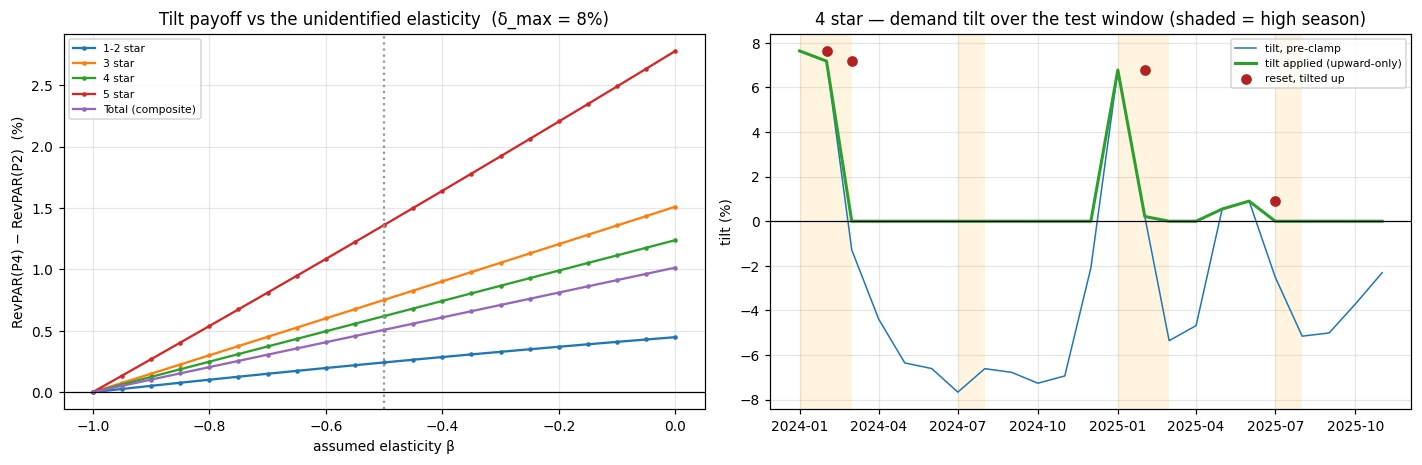

In [7]:
betas = np.round(np.linspace(0.0, -1.0, 21), 3)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))

for c in CATS:
    p = prep[c]
    path4 = simulate_p4(p["s"], C.TEST_SEGMENT, TAU, max(delta_star, 0.05), p["tgt"])
    path2 = PL.simulate(PL.policy2_threshold(TAU), p["s"], C.TEST_SEGMENT,
                        occ_norm=p["occ_norm"], anchor_real=p["tgt"])
    d = []
    for b in betas:
        r4 = EV.score(path4, b, p["tgt"])["total_revpar"]
        r2 = EV.score(path2, b, p["tgt"])["total_revpar"]
        d.append((r4 / r2 - 1) * 100 if r2 else np.nan)
    ax[0].plot(betas, d, marker="o", ms=2, label=LAB[c])
ax[0].axhline(0, color="k", lw=.8)
ax[0].axvline(-0.5, color="0.6", ls=":")
ax[0].set_xlabel("assumed elasticity β")
ax[0].set_ylabel("RevPAR(P4) − RevPAR(P2)  (%)")
ax[0].set_title(f"Tilt payoff vs the unidentified elasticity  (δ_max = {max(delta_star,0.05):.0%})")
ax[0].legend(fontsize=7)

c = "stars_4"; p = prep[c]
sh = p["s"][p["s"].date.between(pd.Timestamp(C.TEST_SEGMENT[0]), pd.Timestamp(C.TEST_SEGMENT[1]))]
dm = max(delta_star, 0.05)
pre = dm * np.tanh(np.nan_to_num(sh["tilt_raw"].to_numpy())) * 100
applied = np.clip(dm * np.tanh(np.nan_to_num(sh["tilt_raw"].to_numpy())), 0, dm) * 100
ax[1].plot(sh.date, pre, color="tab:blue", lw=1, label="tilt, pre-clamp")
ax[1].plot(sh.date, applied, color="tab:green", lw=2, label="tilt applied (upward-only)")
path = simulate_p4(p["s"], C.TEST_SEGMENT, TAU, dm, p["tgt"])
rp = path[path.reprice & (path.tilt_applied > 1e-4)]
ax[1].scatter(rp.date, rp.tilt_applied * 100, color="firebrick", zorder=5, label="reset, tilted up")
for _, r in sh.iterrows():
    if r["date"].month in HI_SEASON:
        ax[1].axvspan(r["date"], r["date"] + pd.offsets.MonthBegin(1), color="orange", alpha=.12, lw=0)
ax[1].axhline(0, color="k", lw=.8)
ax[1].set_ylabel("tilt (%)")
ax[1].set_title(f"{LAB[c]} — demand tilt over the test window (shaded = high season)")
ax[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "08_tilt_payoff.png")
LOG.log("figure", "08_tilt_payoff.png"); plt.show()

## 7 · Verdict

* **Architecturally clean.** P4 = P2's trigger with a tilted reset; `δ_max = 0`
  reproduces P2 exactly. The tilt is bounded and upward-only, so the worst case
  is losing a little occupancy in a demand over-estimate.
* **Real-price stabilisation is preserved.** The tilt is small and fires only at
  resets, so `mean |real dev|` and the change count stay essentially at the P2
  values — P4 does not undo what P2 buys.
* **The revenue case rests entirely on β.** At β ≈ 0 the tilt is a small
  mechanical RevPAR gain, bounded by `δ_max`; by β = −1 it is roughly
  neutral-to-negative. β is not identified (notebook 04), so this is a
  **positioning lever, not a demonstrated improvement**.
* **The signal is thin.** Only occupancy-vs-norm, travellers-vs-norm and an
  occupancy-momentum proxy exist in this data; booking pace, an event calendar
  and real exchange-rate competitiveness do not. A genuine surge layer needs
  firm-level revenue-management data (pickup curves, competitor rates, events).
* **Recommendation unchanged.** Keep P2 as the rule. Any demand tilt should be
  discretionary, applied only at resets, capped and upward-only — and revisited
  when booking-curve data is available.

In [8]:
LOG.flush()
print("08_demand_tilt exploration complete.")

08_demand_tilt exploration complete.
